In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
from PIL import Image
from sklearn.model_selection import train_test_split
import random
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib import pyplot as plt
import lime
from lime import lime_image
import shap
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import cv2  # Import cv2 for image processing
from matplotlib import pyplot as plt
from tensorflow.keras.preprocessing import image
from skimage.transform import resize
from tensorflow.keras.models import Model
# from tf_keras_vis.gradcam import Gradcam

C:\Users\saite\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset_dir = "C:\MAJOR\Dataset\TB_Chest_Radiography_Database"
normal_dir = os.path.join(dataset_dir, "Normal")
tuberculosis_dir = os.path.join(dataset_dir, "Tuberculosis")

In [4]:
def preprocess_images(image_dir, label):
    images = []
    labels = []
    for filename in os.listdir(image_dir):
        if filename.endswith(".png"):
            image_path = os.path.join(image_dir, filename)
            image = Image.open(image_path)
            image = image.convert("RGB")    # Convert grayscale to RGB
            image = image.resize((256, 256))  # Resize images to 256x256 pixels
            image = np.array(image) / 255.0   # Normalize pixel values to [0, 1]
            images.append(image)
            labels.append(label)
    return images, labels

In [5]:
normal_images, normal_labels = preprocess_images(normal_dir, label=0)


In [6]:
tuberculosis_images, tuberculosis_labels = preprocess_images(tuberculosis_dir, label=1)


In [7]:
images = normal_images + tuberculosis_images
labels = normal_labels + tuberculosis_labels

In [8]:
images=np.array(images)
labels=np.array(labels)

In [9]:
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)

In [10]:
print("Train images shape:", train_images.shape)
print("Test images shape:", test_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test labels shape:", test_labels.shape)

Train images shape: (2956, 256, 256, 3)
Test images shape: (739, 256, 256, 3)
Train labels shape: (2956,)
Test labels shape: (739,)


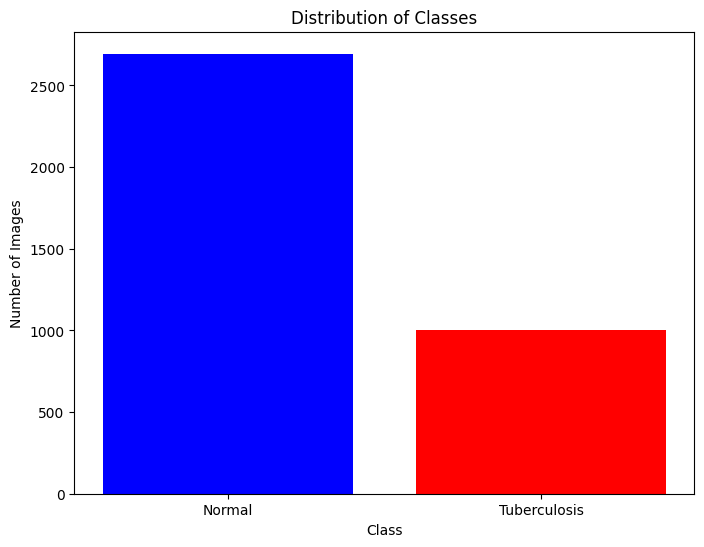

In [11]:
# Visualize the distribution of classes
plt.figure(figsize=(8, 6))
plt.bar(["Normal", "Tuberculosis"], [len(normal_images), len(tuberculosis_images)], color=['blue', 'red'])
plt.title("Distribution of Classes")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

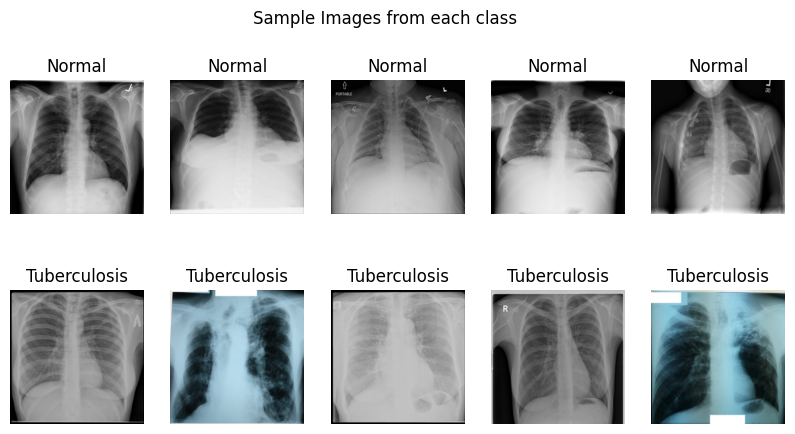

In [12]:
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(normal_images[random.randint(0,len(normal_images)-1)])
    plt.title("Normal")
    plt.axis("off")
    
    plt.subplot(2,5,i+6)
    plt.imshow(tuberculosis_images[random.randint(0,len(tuberculosis_images)-1)])
    plt.title("Tuberculosis")
    plt.axis("off")
plt.suptitle("Sample Images from each class")
plt.show()
    

In [13]:
def create_lenet_model(input_shape, num_classes=1):
    inputs = layers.Input(shape=input_shape)
    
    x = layers.Conv2D(6, (5, 5), activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(16, (5, 5), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(120, activation='relu')(x)
    x = layers.Dense(84, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='sigmoid')(x)  # Output layer

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Example usage:
input_shape = (256, 256, 3)  # Example input shape
num_classes = 1  # Example number of classes for binary classification
lenet_model = create_lenet_model(input_shape, num_classes)

# Print model summary
lenet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 252, 252, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 126, 126, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 16)   │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 59536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │     7,144,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,157,561 (27.30 MB)

 Trainable params: 7,157,561 (27.30 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
lenet_model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])


In [15]:
history = lenet_model.fit(train_images, train_labels,
                          epochs=50,
                          batch_size=32,
                          validation_data=(test_images, test_labels))

Epoch 1/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 26s 212ms/step - accuracy: 0.8084 - loss: 0.4555 - val_accuracy: 0.9283 - val_loss: 0.1638
Epoch 2/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 18s 191ms/step - accuracy: 0.9547 - loss: 0.1253 - val_accuracy: 0.9567 - val_loss: 0.1207
Epoch 3/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 18s 188ms/step - accuracy: 0.9566 - loss: 0.1115 - val_accuracy: 0.9635 - val_loss: 0.1002
Epoch 4/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 17s 186ms/step - accuracy: 0.9842 - loss: 0.0503 - val_accuracy: 0.9648 - val_loss: 0.0778
Epoch 5/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 17s 186ms/step - accuracy: 0.9730 - loss: 0.0762 - val_accuracy: 0.9594 - val_loss: 0.1043
Epoch 6/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 17s 183ms/step - accuracy: 0.9609 - loss: 0.1042 - val_accuracy: 0.9648 - val_loss: 0.0975
Epoch 7/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 17s 186ms/step - accuracy: 0.9866 - loss: 0.0472 - val_accuracy: 0.9662 - val_loss: 0.0746
Epoch 8/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 17s 179ms/step - accuracy: 0.9892 - loss: 0.0300 - val_accu

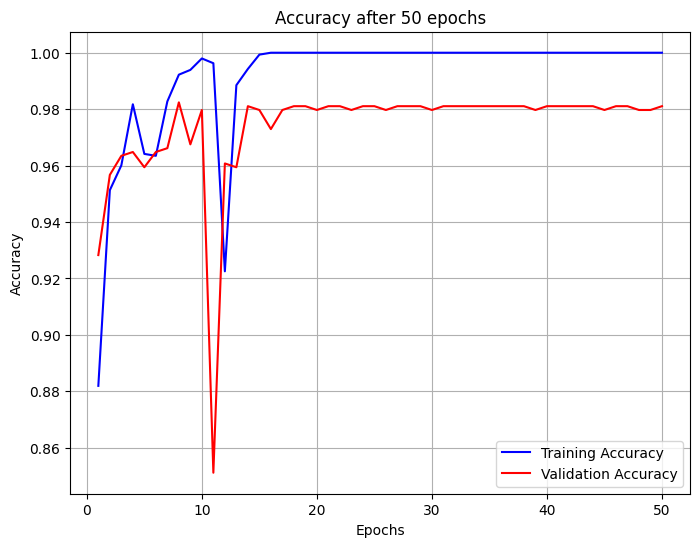

In [17]:
import matplotlib.pyplot as plt

# Extract accuracy and validation accuracy from history
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']

# Plot training and validation accuracy
epochs = range(1, len(training_accuracy) + 1)
plt.figure(figsize=(8, 6))
plt.plot(epochs, training_accuracy, 'b-', label='Training Accuracy')
plt.plot(epochs, validation_accuracy, 'r-', label='Validation Accuracy')
plt.title('Accuracy after 50 epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [37]:
test_loss, test_accuracy = lenet_model.evaluate(test_images, test_labels)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9836 - loss: 0.1026
Test Loss: 0.13437700271606445
Test Accuracy: 0.981055498123169


In [18]:
y_pred_probs = lenet_model.predict(test_images)

# Convert probabilities to binary predictions
y_pred_binary = (y_pred_probs > 0.5).astype(int)

# Convert test labels to binary format (0: Normal, 1: Tuberculosis)
test_labels_binary = (test_labels > 0.5).astype(int)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


In [19]:
classification_metrics = classification_report(test_labels_binary, y_pred_binary)
print("Classification Report:")
print(classification_metrics)

# Confusion matrix
conf_matrix = confusion_matrix(test_labels_binary, y_pred_binary)
print("Confusion Matrix:")
print(conf_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       539
           1       0.97      0.95      0.96       200

    accuracy                           0.98       739
   macro avg       0.98      0.97      0.98       739
weighted avg       0.98      0.98      0.98       739

Confusion Matrix:
[[534   5]
 [  9 191]]


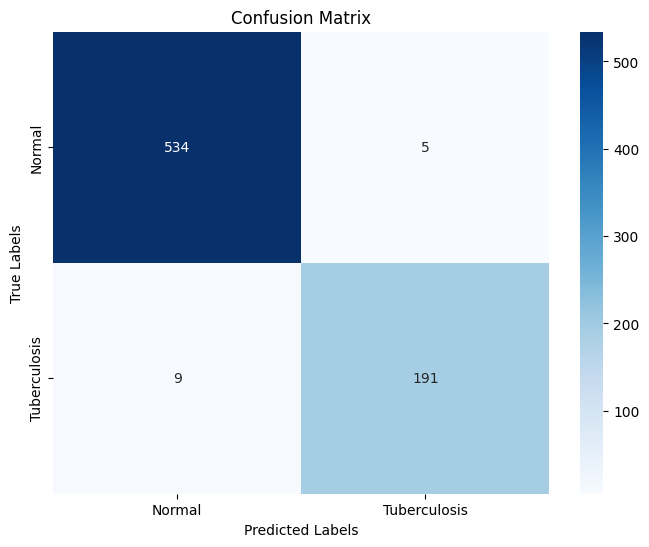

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Compute confusion matrix
conf_matrix = confusion_matrix(test_labels_binary, y_pred_binary)

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Tuberculosis'], yticklabels=['Normal', 'Tuberculosis'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [34]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Load and preprocess the image
def preprocess_image(img_path, target_size=(64, 64)):  # Update target_size as per model input shape
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Ensure color_mode is correct
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = img_array / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Predict function
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  # Match model input size
    prediction = model.predict(processed_image)
    predicted_class = int(prediction > threshold)  # Convert probability to binary class
    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return prediction[0][0], class_label

# Example usage
img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Tuberculosis\Tuberculosis-13.png"  # Use raw string for Windows paths
probability, label = predict_tb(img_path, lenet_model)

print(f"Predicted Probability: {probability:.2f}")
print(f"Prediction: {label}")




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Probability: 1.00
Prediction: Tuberculosis


C:\Users\saite\AppData\Local\Temp\ipykernel_2320\261703951.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted_class = int(prediction > threshold)  # Convert probability to binary class


In [33]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Load and preprocess the image
def preprocess_image(img_path, target_size=(64, 64)):  # Update target_size as per model input shape
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Ensure color_mode is correct
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = img_array / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Predict function
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  # Match model input size
    prediction = model.predict(processed_image)
    predicted_class = int(prediction > threshold)  # Convert probability to binary class
    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return prediction[0][0], class_label

# Example usage
img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal\Normal-9.png" 
probability, label = predict_tb(img_path, lenet_model)

print(f"Predicted Probability: {probability:.2f}")
print(f"Prediction: {label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Probability: 0.00
Prediction: Normal


C:\Users\saite\AppData\Local\Temp\ipykernel_2320\26100425.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted_class = int(prediction > threshold)  # Convert probability to binary class


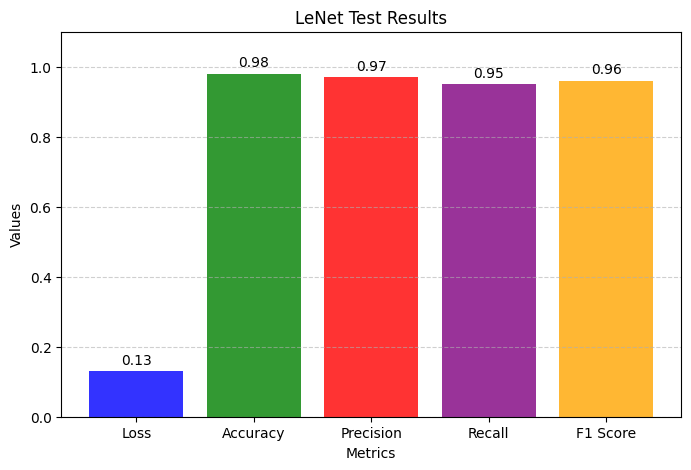

In [38]:
import matplotlib.pyplot as plt

def visualize_lenet_test_results(results):
    """
    Visualize the test results for the LeNet model using a bar chart.
    
    Parameters:
    - results: A list containing values for Loss, Accuracy, Precision, Recall, and F1 Score.
    """
    labels = ['Loss', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
    values = results[:5]  # Ensuring that only the first 5 elements are used for visualization

    # Define bar colors for better visualization
    colors = ['blue', 'green', 'red', 'purple', 'orange']

    # Plotting the bar graph
    plt.figure(figsize=(8, 5))
    plt.bar(labels, values, color=colors, alpha=0.8)
    plt.title('LeNet Test Results')
    plt.xlabel('Metrics')
    plt.ylabel('Values')
    plt.ylim(0, 1.1)  # Assuming metrics range between 0 and 1, adjust as needed
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Annotating each bar with its value
    for i, value in enumerate(values):
        plt.text(i, value + 0.02, f"{value:.2f}", ha='center', fontsize=10, color='black')

    plt.show()

# Example usage
test_results = [0.13, 0.98, 0.97, 0.95, 0.96]  # Example values for Loss, Accuracy, Precision, Recall, F1 Score
visualize_lenet_test_results(test_results)


In [40]:
from tensorflow.keras.models import load_model
lenet_model.save("LeNet.h5")

In [50]:
predictions = lenet_model.predict(test_images)

# Print the shape of the predictions array
print("Shape of predictions array:", predictions.shape)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
Shape of predictions array: (739, 1)


In [51]:
import tensorflow.keras as K
last_conv_layer = next(x for x in lenet_model.layers[::-1] if isinstance(x, K.layers.Conv2D))
last_conv_layer.name

'conv2d_1'

In [53]:
spatial_maps =  lenet_model.get_layer('conv2d_1').output
print(spatial_maps)

<KerasTensor shape=(None, 122, 122, 16), dtype=float32, sparse=False, name=keras_tensor_3>


In [54]:
output_with_batch_dim = lenet_model.output
print(f"Model output includes batch dimension, has shape {output_with_batch_dim.shape}")
print(f"excluding the batch dimension, the output for all 14 categories of disease has shape {output_with_batch_dim[0].shape}")

Model output includes batch dimension, has shape (None, 1)
excluding the batch dimension, the output for all 14 categories of disease has shape (1,)


In [71]:
def GradCAM(model, image, interpolant=0.5, plot_results=True):
    assert (interpolant > 0 and interpolant < 1), "Heatmap Interpolation Must Be Between 0 - 1"

    # Preprocess image and make prediction using our model
    original_img = np.asarray(image, dtype=np.float32)
    img = np.expand_dims(original_img, axis=0)

    # Predict
    prediction = model.predict(img)
    prediction_idx = np.argmax(prediction)

    # Find the last convolutional layer
    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer
            break

    if last_conv_layer is None:
        raise ValueError("No convolutional layer found in the model.")

    # Create a model to extract feature maps and predictions
    gradient_model = Model(inputs=model.inputs, outputs=[last_conv_layer.output, model.output])

    # Compute gradient of top predicted class
    with tf.GradientTape() as tape:
        conv2d_out, prediction = gradient_model(img)
        loss = prediction[:, prediction_idx]

    gradients = tape.gradient(loss, conv2d_out)

    output = conv2d_out[0]
    weights = tf.reduce_mean(gradients[0], axis=(0, 1))

    activation_map = np.zeros(output.shape[0:2], dtype=np.float32)

    for idx, weight in enumerate(weights):
        activation_map += weight * output[:, :, idx]

    activation_map = cv2.resize(activation_map.numpy(), (original_img.shape[1], original_img.shape[0]))
    activation_map = np.maximum(activation_map, 0)
    activation_map = (activation_map - activation_map.min()) / (activation_map.max() - activation_map.min())
    activation_map = np.uint8(255 * activation_map)

    heatmap = cv2.applyColorMap(activation_map, cv2.COLORMAP_JET)

    original_img = np.uint8((original_img - original_img.min()) / (original_img.max() - original_img.min()) * 255)
    cvt_heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    if plot_results:
        plt.imshow(np.uint8(original_img * interpolant + cvt_heatmap * (1 - interpolant)))
    else:
        return cvt_heatmap

In [72]:
def preprocess_images(image_dir, label):
    images = []
    labels = []
    for filename in os.listdir(image_dir):
        if filename.endswith(".png"):
            image_path = os.path.join(image_dir, filename)
            image = Image.open(image_path)
            image = image.convert("RGB")    
            image = image.resize((256, 256))  
            image = np.array(image) / 255.0   # Normalize pixel values to [0, 1]
            images.append(image)
            labels.append(label)
    return images, labels

In [ ]:
test_images, _ = preprocess_images(r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal", label=0)
test_img = test_images[200]

GradCAM(lenet_model, test_img, plot_results=True)

In [1]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load and preprocess the image
def preprocess_image(img_path, target_size=(64, 64)):  # Update target_size as per model input shape
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Ensure color_mode is correct
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = img_array / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Predict function
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  # Match model input size
    prediction = model.predict(processed_image)
    predicted_class = int(prediction > threshold)  # Convert probability to binary class
    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return prediction[0][0], class_label

# Load the trained model
model = load_model("LeNet.h5")

# Example usage
img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Tuberculosis\Tuberculosis-16.png"  
probability, label = predict_tb(img_path, model)

print(f"Predicted Probability: {probability:.2f}")
print(f"Prediction: {label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
Predicted Probability: 1.00
Prediction: Tuberculosis


C:\Users\saite\AppData\Local\Temp\ipykernel_6164\1609418365.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted_class = int(prediction > threshold)  # Convert probability to binary class
